## Modelo no Supervisado

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

import geopandas as gpd


In [20]:
# Cargar grilla de agua con condiciones oceánicas
df = pd.read_parquet("../data/grid_ocean/grilla_agua.parquet")

# Ver columnas
print(df.columns)
print(df.shape)


Index(['lat', 'lon', 'distance_to_coast_km', 'temperature', 'salinity',
       'chlorophyll', 'nitrate', 'phosphate', 'oxygen_dissolved',
       'oxygen_utilization'],
      dtype='object')
(127013, 10)


In [21]:
# Escalar variables
features = ['distance_to_coast_km','temperature','salinity','chlorophyll',
            'nitrate','phosphate','oxygen_dissolved','oxygen_utilization']

X = df[features].values
X_scaled = StandardScaler().fit_transform(X)


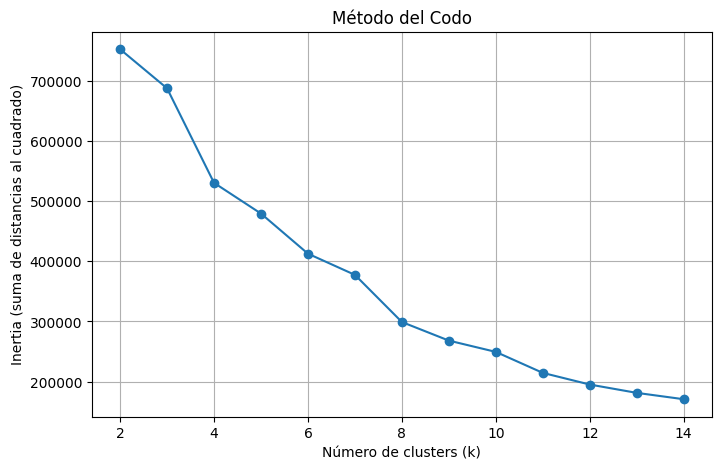

In [22]:
# Elegir el mejor valor de k usando el
# Método del codo (Elbow)

inertia = []
K_range = range(2, 15)  # probar de 2 a 15 clusters

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)  # suma de distancias al cuadrado dentro de cada cluster

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inertia (suma de distancias al cuadrado)')
plt.title('Método del Codo')
plt.grid(True)
plt.show()





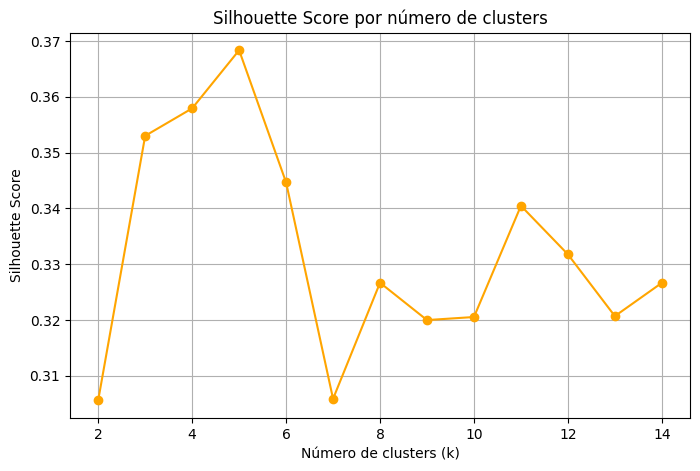

In [23]:
# Método Silhouette Score

# 10k puntos aleatorios (tarda mucho con el dataset completo)
np.random.seed(42)
sample_idx = np.random.choice(X_scaled.shape[0], size=10000, replace=False)
X_sample = X_scaled[sample_idx]

sil_scores = []

for k in range(2, 15):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_sample)
    score = silhouette_score(X_sample, labels)
    sil_scores.append(score)

plt.figure(figsize=(8,5))
plt.plot(K_range, sil_scores, marker='o', color='orange')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score por número de clusters')
plt.grid(True)
plt.show()

Codo: busca el punto donde la línea de inertia deja de bajar de forma pronunciada. Ahí está el “codo” → buen número de clusters.

Silhouette: busca el máximo → el k donde los clusters son más coherentes y separados.

Probamos con K = 5, 6 y 7

In [24]:
# Entrenar KMeans para k=5,6,7 y creamos las columnas de clusters

cluster_results = {}

for k in [5, 6, 7]:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    df[f'cluster_{k}'] = labels
    cluster_results[k] = kmeans


In [25]:
# Creamos geodataframe final con perfiles ecológicos
grid_gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.lon, df.lat), crs="EPSG:4326")

<Figure size 1200x600 with 0 Axes>

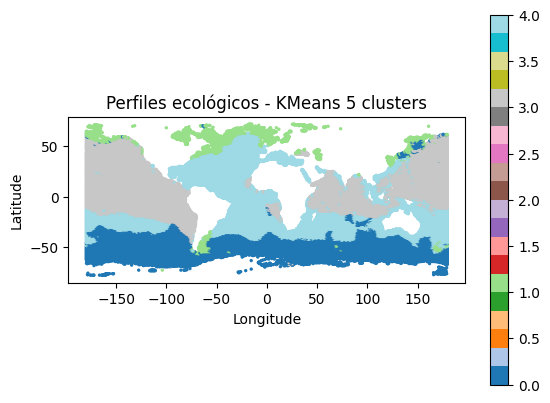

<Figure size 1200x600 with 0 Axes>

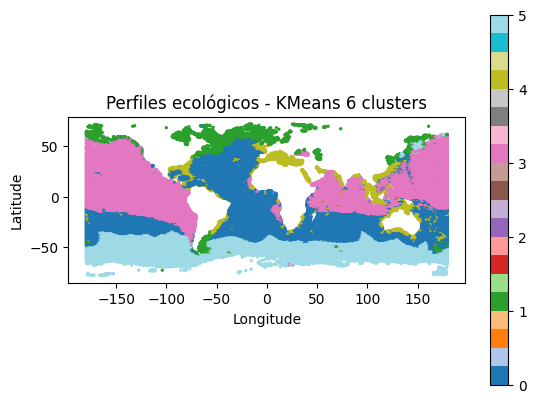

<Figure size 1200x600 with 0 Axes>

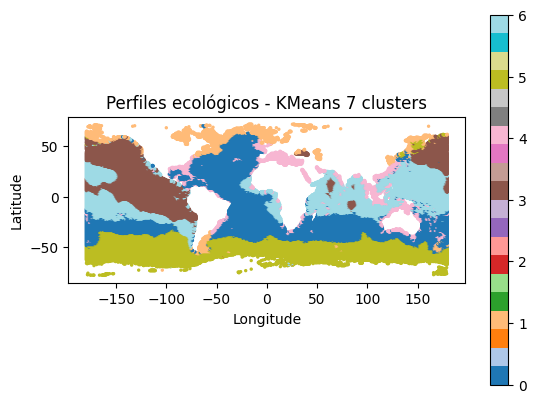

In [26]:
for k in [5,6,7]:
    plt.figure(figsize=(12,6))
    grid_gdf.plot(column=f'cluster_{k}', cmap='tab20', markersize=2, legend=True)
    plt.title(f"Perfiles ecológicos - KMeans {k} clusters")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.show()

In [27]:
# Calcular medias por cluster
for k in [5,6,7]:
    print(f"\n=== Medias de variables por cluster (k={k}) ===")
    print(df.groupby(f'cluster_{k}')[features].mean())



=== Medias de variables por cluster (k=5) ===
           distance_to_coast_km  temperature   salinity  chlorophyll  \
cluster_5                                                              
0                   1123.567079     3.684880  34.488426     1.497318   
1                    227.127088     4.759461  32.609127     0.960865   
2                    317.600858     0.244107  34.535980 -1120.288208   
3                    682.457293     8.958219  34.606510    -0.058779   
4                    560.724956    11.158368  35.185234     0.323362   

             nitrate  phosphate  oxygen_dissolved  oxygen_utilization  
cluster_5                                                              
0          26.777117   1.882050        229.695740           94.592758  
1          10.057297   0.954944        294.823334           26.208197  
2          31.178432   2.124543        246.713226          103.628891  
3          27.525665   2.040388        128.058411          165.236298  
4          16.58

Nos quedamos con k=6 porque divide mejor el mapa global, separando zonas frias, templadas y zonas de costa

In [28]:
# Asignar nombres descriptivos a los clusters para k=6
# Diccionario de mapeo.
cluster_names = {
    0: "open_sea_temperate",
    1: "cold_shelf",
    2: "invalid_data",   # opcional: eliminar filas con cluster 2 más adelante
    3: "subpolar_open_sea",
    4: "warm_coastal",
    5: "cold_open_sea"
}

# Crear nueva columna con nombres descriptivos
grid_gdf['profile_eco'] = grid_gdf['cluster_6'].map(cluster_names)

# Eliminar filas con datos inválidos
grid_gdf = grid_gdf[grid_gdf['profile_eco'] != "invalid_data"]

# Revisar resultados
grid_gdf[['cluster_6','profile_eco']]


,cluster_6,profile_eco
0,5,cold_open_sea
1,5,cold_open_sea
2,5,cold_open_sea
3,5,cold_open_sea
4,5,cold_open_sea
...,...,...
127008,1,cold_shelf
127009,1,cold_shelf
127010,1,cold_shelf
127011,1,cold_shelf


In [29]:
(grid_gdf["profile_eco"]).value_counts()

profile_eco
subpolar_open_sea     42937
open_sea_temperate    42489
cold_open_sea         31145
cold_shelf             5601
warm_coastal           4839
Name: count, dtype: int64

In [30]:
grid_gdf = grid_gdf.drop(columns=['cluster_5','cluster_7'])
grid_gdf = grid_gdf.rename(columns={'cluster_6':'cluster_num'})
grid_gdf

,lat,lon,distance_to_coast_km,temperature,salinity,chlorophyll,nitrate,phosphate,oxygen_dissolved,oxygen_utilization,cluster_num,geometry,profile_eco
0,-78.0,-175.5,543.707048,-1.775068,34.395912,1.680748,27.419722,1.907441,311.153168,59.152695,5,POINT (-175.5 -78),cold_open_sea
1,-78.0,-175.0,533.294654,-1.775068,34.395912,1.243596,27.419722,1.907441,311.153168,59.152695,5,POINT (-175 -78),cold_open_sea
2,-78.0,-173.0,543.143622,-1.808737,34.373737,-0.760849,27.574869,1.912899,312.213226,57.888039,5,POINT (-173 -78),cold_open_sea
3,-78.0,-172.5,540.559218,-1.808737,34.373737,-0.805667,27.574869,1.912899,312.213226,57.888039,5,POINT (-172.5 -78),cold_open_sea
4,-78.0,-172.0,535.905487,-1.808737,34.373737,-0.708566,27.574869,1.912899,312.213226,57.888039,5,POINT (-172 -78),cold_open_sea
...,...,...,...,...,...,...,...,...,...,...,...,...,...
127008,72.0,-15.0,425.634963,0.289420,34.764435,0.504466,11.316046,0.823883,318.571198,32.765865,1,POINT (-15 72),cold_shelf
127009,72.0,25.5,94.266326,6.833642,34.894951,0.065487,6.138589,0.608244,298.023193,4.414944,1,POINT (25.5 72),cold_shelf
127010,72.0,26.5,110.341777,6.723017,34.888157,0.365244,5.862425,0.607004,298.572815,4.962784,1,POINT (26.5 72),cold_shelf
127011,72.0,27.0,111.642511,6.723017,34.888157,-0.597254,5.862425,0.607004,298.572815,4.962784,1,POINT (27 72),cold_shelf


In [47]:
grid_gdf.to_file(
    "../data/grid_ocean/grilla_agua_perfiles.gpkg",
    driver="GPKG"
)
